## Injecting MBBH data to simulated TDI noise
BBHx package can be used to generate MBBH (massive binary black hole merger) waveform. This notebook contains the code to add MBBH signals to simulated TDI noise.

In [16]:
import os as os
import sys

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bbhx.utils.constants import *
from bbhx.utils.transform import *
from lisa_mbbh_strain import *
from scripts.readTdi import getTdiPath, readTdi
from psd_estimation_methods.wosa import wosa
from scripts.plot import plot
np.random.seed(111222)

For estimating PSD, we divide the time series into segments, find the PSD for each of the segment, and find the average or median PSD. The following function can be used to plot the PSDs of each of the segments.

In [17]:
def plot_segments_from_series(
        series_list,          # list of 1-D arrays: [sig1, sig2, …]
        labels,               # matching list of short strings
        fs,                   # sampling frequency (Hz)
        nperseg   = 2000,     # same nperseg you use in wosa
        method    = "mean",   # "mean" or "median"
        alpha     = 0.7,      # transparency of lines
        colours   = None      # optional list of colour strings
    ):
    """
    Overlay log–log WOSA spectra of matching segments from multiple
    time-series.  Each row = one segment index (up to the longest series).

    Example call:
        plot_segments_from_series(
            [signal_and_noise, data_orig],
            ["signal+noise", "noise only"],
            fs=fs
        )
    """
    # ------------------------------------------------------------
    # 1) run WOSA on every array and collect results
    # ------------------------------------------------------------
    all_specs = []     # [{label, f, P_stack}, …]
    max_seg   = 0

    for k, (x, lab) in enumerate(zip(series_list, labels)):
        f, _, P_stack, _ = wosa(
            x=x, fs=fs, nperseg=nperseg, method=method
        )

        # ditch the zero-Hz bin (log scale problem)
        if f[0] == 0:
            f        = f[1:]
            P_stack  = P_stack[:, 1:]

        all_specs.append(dict(label=lab, f=f, P_stack=P_stack))
        max_seg = max(max_seg, P_stack.shape[0])

    # ------------------------------------------------------------
    # 2) build a subplot per segment index
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        max_seg, 1, sharex=True,
        figsize=(7, 2*max_seg),
        constrained_layout=True
    )
    if max_seg == 1:               # keep iterable even with 1 segment
        axes = [axes]

    for seg, ax in enumerate(axes):
        for j, spec in enumerate(all_specs):
            if seg >= spec["P_stack"].shape[0]:
                continue           # this series had fewer segments

            color = None if colours is None else colours[j]
            ax.loglog(
                spec["f"],
                spec["P_stack"][seg],
                lw=1, alpha=alpha,
                color=color,
                label=spec["label"]
            )

        ax.set_ylabel(f"seg {seg+1}")
        if seg == 0:
            ax.legend(fontsize="small")

    axes[-1].set_xlabel("Frequency [Hz]")
    fig.suptitle("WOSA segment spectra (log–log overlay)", y=1.02)
    plt.show()

The following code generates MBBH signal, TDI-noise, and adds them.

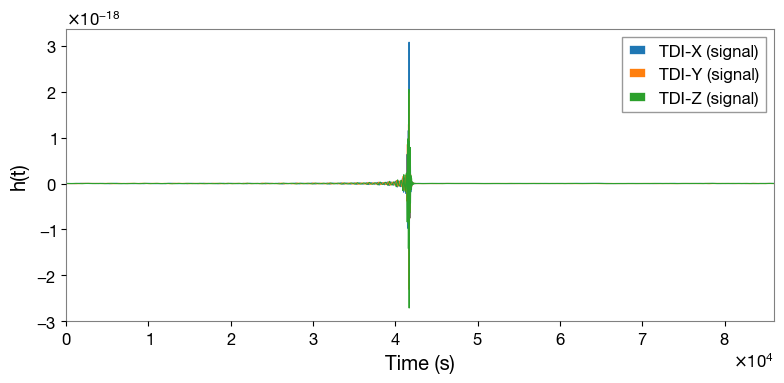

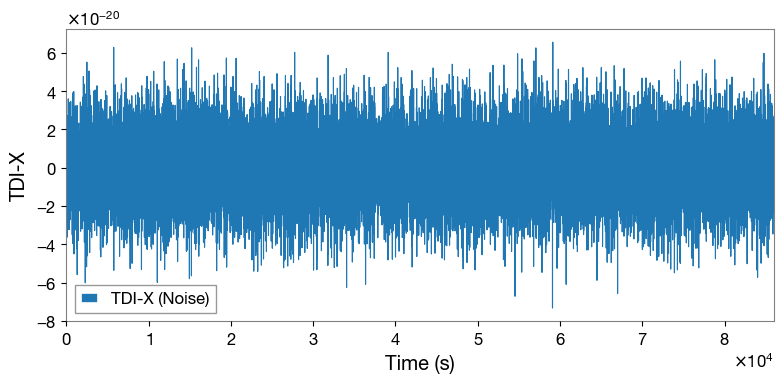

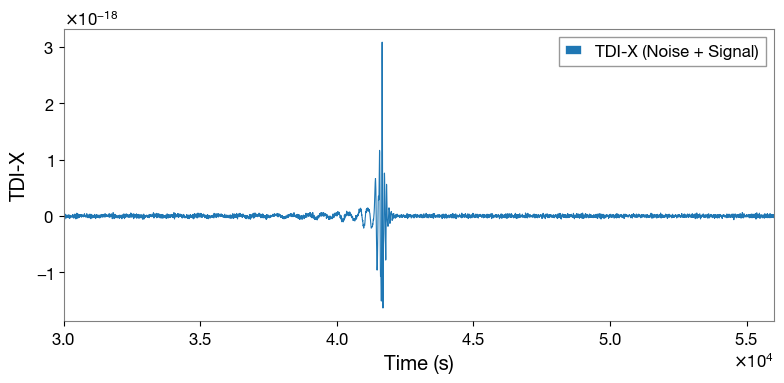

In [18]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)

plt.figure(figsize=(8,4))
plt.plot(t_mbbh, hX, lw=0.8, label='TDI-X (signal)')
plt.plot(t_mbbh, hY, lw=0.8, label='TDI-Y (signal)')
plt.plot(t_mbbh, hZ, lw=0.8, label='TDI-Z (signal)')
plt.xlabel('Time (s)')
plt.ylabel('h(t)')
plt.xlim(t_mbbh[0], t_mbbh[-1])
# plt.xlim(35000, 44000)
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()


# Generate and plot noise
tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)

plt.figure(figsize=(8,4))
plt.plot(t, tdi_noise, lw=0.8, label='TDI-X (Noise)')
plt.xlabel('Time (s)')
plt.ylabel('TDI-X')
plt.xlim(t[0], t[-1])
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()


# plot noise + signal
signal_and_noise = tdi_noise+hX
plt.figure(figsize=(8,4))
plt.plot(t, signal_and_noise, lw=0.8, label='TDI-X (Noise + Signal)')
plt.xlabel('Time (s)')
plt.ylabel('TDI-X')
plt.xlim(t[0], t[-1])
plt.grid(False)
plt.xlim(30000, 56000)
plt.legend(); plt.tight_layout(); plt.show()
# "location of constellation" should be same for tdi-noise and signal

We estimate the PSD of MBBH signal + TDI noise:

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

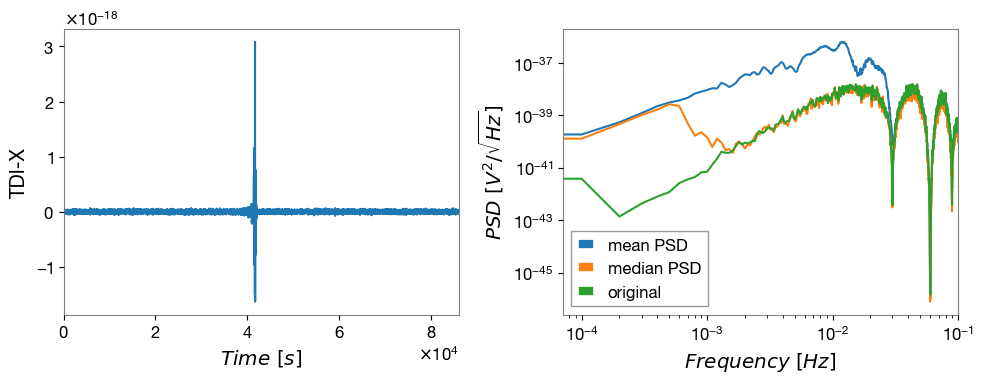

In [19]:
nperseg = 2000

tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, P_stack, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)


The median-based method fails to estimate the true PSD at low frequencies, as the plots below show. We split the time series into 16 segments, and in each segment the PSD for the noise-only TDI and the TDI+MBBH case differ. This means the middle segment is also affected, so the median gets biased too.

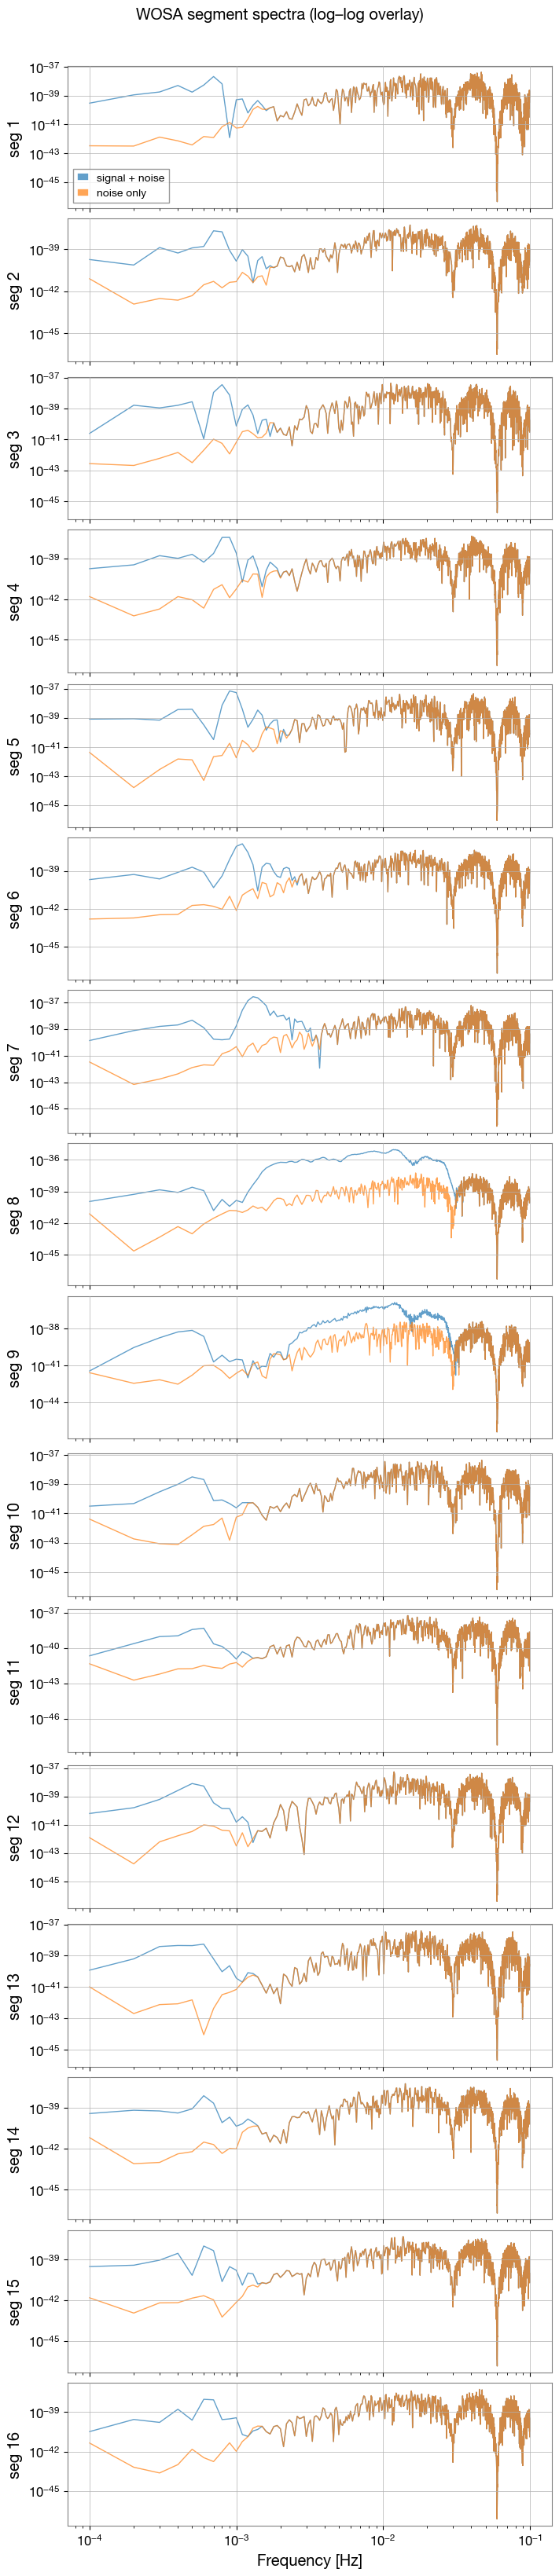

In [20]:
nperseg = 2000

tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)

# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)
signal_and_noise = tdi_noise+hX


plot_segments_from_series(
    [signal_and_noise, tdi_noise],
    ["signal + noise", "noise only"],
    fs=fs
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

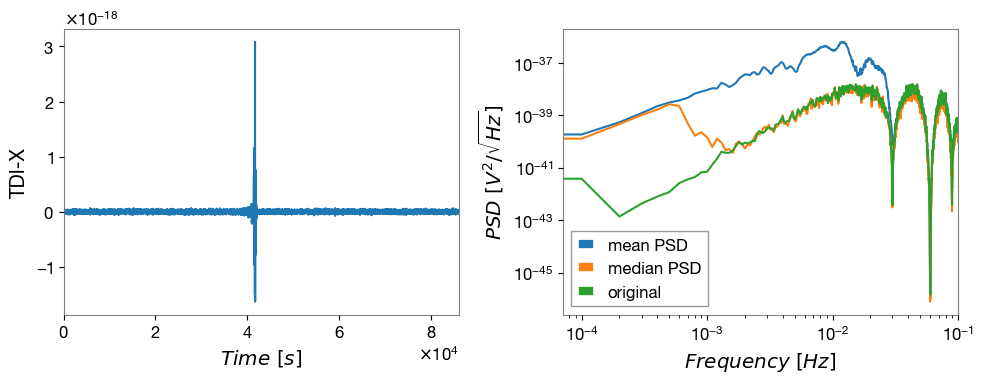

In [21]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)
tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# 1 signal to a longer data 
# larger and smaller amplitude for the mbbh signal 

MBBH with smaller amplitude:

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

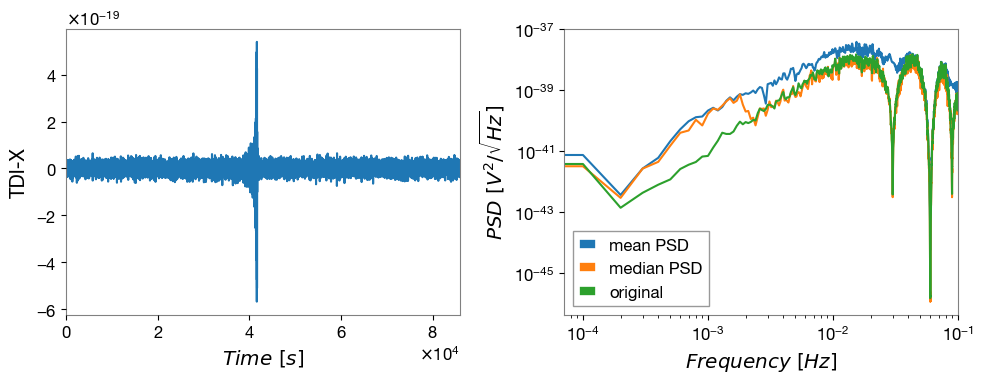

In [22]:
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e5, m2=5e4,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    N=17200,
    t_ref=0.5 * YRSID_SI,
    dt=5.0
)

tdi_path = getTdiPath('glitch_1.h5')
tdi_noise, fs, t = readTdi(tdi_path)
signal_and_noise = tdi_noise+hX

nperseg = 2000
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_mean, psd_mean, _, nseg = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="mean"
)

# compute median‐PSD
f_median, psd_median, _, _ = wosa(
    x=signal_and_noise,
    fs=fs,
    nperseg=nperseg,
    method="median"
)

# plot all three curves (assuming psd_orig is defined)
plot(
    data=signal_and_noise,
    t=t,
    f=f_mean,
    psd=[psd_mean, psd_median, psd_orig],
    labels=["mean PSD", "median PSD", "original"],
    title=f"TDI-X",
    f_lims=[f_mean[0], f_mean[-1]]
)

# shifting injection to left

## Noise artifacts from inverse-FFT

In the MBBH case, once the merger is complete the signal should drop to 0. But in the plot below (right side, between t=5e4 to t=8e4), you can still see some sinusoidal waves. These are just noise artifacts. The MBBH strain is generated in the frequency domain and then inverse Fourier transformed to the time domain, and hence we get these artifacts

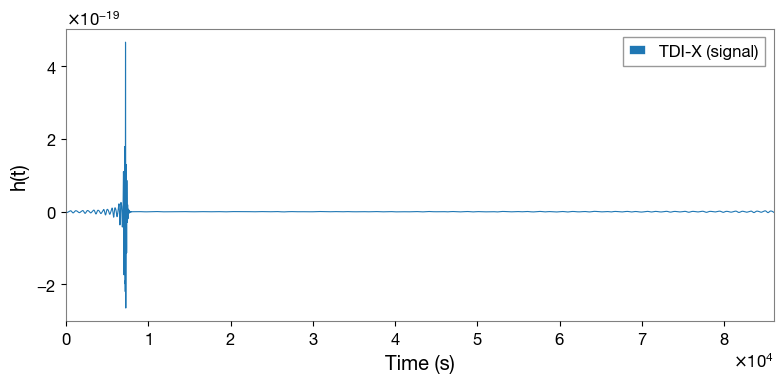

In [23]:
# Generate and plot signal
t_mbbh, hX, hY, hZ = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3, # inc=np.pi/3,
    lam=np.pi/5, # lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6, # psi=np.pi/6,
    N=17200,
    t_ref=0.3 * YRSID_SI,
    dt=5.0
)

plt.figure(figsize=(8,4))
plt.plot(t_mbbh, hX, lw=0.8, label='TDI-X (signal)')
plt.xlabel('Time (s)')
plt.ylabel('h(t)')
plt.xlim(t_mbbh[0], t_mbbh[-1])
# plt.xlim(35000, 44000)
plt.grid(False)
plt.legend(); plt.tight_layout(); plt.show()

# 15779074.881772801